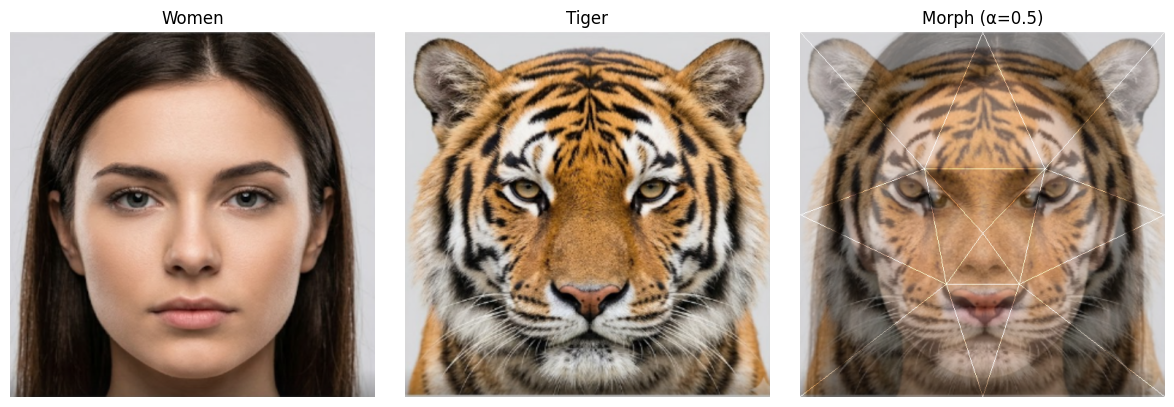

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Load images ────────────────────────────────────────────────────────────────
a = cv2.imread("CVLab02/assets/women.png")
b = cv2.imread("CVLab02/assets/tiger.png")
if a is None: a = cv2.imread("../CVLab02/assets/women.png")
if b is None: b = cv2.imread("../CVLab02/assets/tiger.png")

W, H = 500, 500
alpha = 0.5  # 0 = full women, 1 = full tiger, 0.5 = 50-50 mix

# Resize and convert BGR→RGB
img1 = cv2.cvtColor(cv2.resize(a, (W, H)), cv2.COLOR_BGR2RGB).astype(np.float32)
img2 = cv2.cvtColor(cv2.resize(b, (W, H)), cv2.COLOR_BGR2RGB).astype(np.float32)

# ── Step 1: Mark face landmarks (eyes, nose, mouth) on both images ─────────────
# These points tell the algorithm WHAT to align (eye→eye, mouth→mouth, etc.)
face1 = np.float32([[150,185],[350,185],[250,270],[195,350],[305,350]])  # women
face2 = np.float32([[190,190],[320,190],[250,280],[205,340],[295,340]])  # tiger

# Also add image corners so the whole image is covered, not just the face
corners = np.float32([[0,0],[W-1,0],[W-1,H-1],[0,H-1],
                       [W//2,0],[W-1,H//2],[W//2,H-1],[0,H//2]])

p1 = np.vstack([face1, corners])  # all landmarks for image 1
p2 = np.vstack([face2, corners])  # all landmarks for image 2
pm = (1 - alpha) * p1 + alpha * p2  # midpoint landmarks (morph target)

# ── Step 2: Triangulate the midpoint landmarks (Delaunay triangulation) ─────────
# Splits the image into triangles so we can warp each triangle independently
sub = cv2.Subdiv2D((0, 0, W, H))
for x, y in pm:
    sub.insert((float(x), float(y)))

# Convert triangle coordinates → landmark indices
tris = []
for t in sub.getTriangleList():
    pts = np.float32(t).reshape(3, 2)
    ids = [np.argmin(np.sum((pm - p)**2, axis=1)) for p in pts]
    tris.append(ids)

# ── Step 3: Warp each triangle from source → morph position ────────────────────
def warp_triangle(src_img, src_pts, dst_pts, canvas):
    # Bounding box of destination triangle
    r = cv2.boundingRect(dst_pts)
    # Shift points to local bounding-box coordinates
    src_local = src_pts - [cv2.boundingRect(src_pts)[0], cv2.boundingRect(src_pts)[1]]
    dst_local = dst_pts - [r[0], r[1]]
    # Crop the source patch and warp it to fit the destination triangle shape
    patch = src_img[cv2.boundingRect(src_pts)[1] : cv2.boundingRect(src_pts)[1]+cv2.boundingRect(src_pts)[3],
                    cv2.boundingRect(src_pts)[0] : cv2.boundingRect(src_pts)[0]+cv2.boundingRect(src_pts)[2]]
    M = cv2.getAffineTransform(src_local.astype(np.float32), dst_local.astype(np.float32))
    warped = cv2.warpAffine(patch, M, (r[2], r[3]), borderMode=cv2.BORDER_REFLECT_101)
    # Create a triangle-shaped mask so we only paste inside the triangle
    mask = np.zeros((r[3], r[2], 3), np.float32)
    cv2.fillConvexPoly(mask, np.int32(dst_local), (1,1,1), lineType=cv2.LINE_AA)
    # Paste warped triangle onto canvas
    canvas[r[1]:r[1]+r[3], r[0]:r[0]+r[2]] += warped * mask

# Warp both images toward the morph midpoints
out1, out2 = np.zeros_like(img1), np.zeros_like(img2)
for ids in tris:
    warp_triangle(img1, p1[ids], pm[ids], out1)
    warp_triangle(img2, p2[ids], pm[ids], out2)

# ── Step 4: Blend the two warped images ────────────────────────────────────────
result = np.clip((1 - alpha) * out1 + alpha * out2, 0, 255).astype(np.uint8)

# ── Show result ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, title in zip(axes,
    [img1.astype(np.uint8), img2.astype(np.uint8), result],
    ["Women", "Tiger", f"Morph (α={alpha})"]):
    ax.imshow(im); ax.set_title(title); ax.axis("off")
plt.tight_layout()
plt.show()